### Practical Work
Dataset: GB1 Data


In [1]:
# Imports
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from split.create_split import create_split

import mavenn
import torch

from models import mlp_oracle
from models.random_forest import RandomForestPredictor
from models.single_mutant_walker import SMW
from main_scorer import plot_results, mutate_score_sequence_GB1, plot_results_normalized, plot_umap_embedding



import matplotlib.pyplot as plt

SEED = 42
AA_List = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

2026-02-24 14:00:07.160778: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper methods to one-hot-encode sequences
AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'
vocab_size = len(AMINO_ACIDS)  # 20 amino acids
aa_to_idx = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

def sequences_to_indices(sequences):
    """Convert sequences of amino acids to sequences of indices."""
    return [aa_to_idx.get(aa, 0) for aa in sequences]

def one_hot(sequences, vocab_size):
    """One-hot encode sequences (2D array of indices)."""
    one_hot = np.zeros((sequences.shape[0], sequences.shape[1], vocab_size), dtype=np.float32)
    for i in range(sequences.shape[0]):
        for j in range(sequences.shape[1]):
            aa_index = sequences[i, j]
            if aa_index < vocab_size:
                one_hot[i, j, aa_index] = 1.0
    return one_hot

def one_hot_encode(sequence) -> np.ndarray:
        """One-hot encode a sequence and flatten it.

        Args:
            sequence: List of nucleotide indices.

        Returns:
            Flattened one-hot encoded sequence of shape (1, seq_len * n).
        """
        sequence_tensor = tf.one_hot(sequence, depth=20)
        sequence_numpy = sequence_tensor.numpy()
        shape = sequence_numpy.shape[0] * sequence_numpy.shape[1]
        sequence_n_flat = sequence_numpy.reshape(1, shape)
        return sequence_n_flat

In [3]:
# Load dataset: GFP
df = mavenn.load_example_dataset('gb1')
df = df[['y', 'x']]
df.columns = ['binding_scores', 'sequence']
df['split'] = ['None'] * len(df)
print("data_loaded with shape:", df.shape)

df['split'] = ['None'] * len(df)

# Sequences to indices
df['encoded_sequence'] = df['sequence'].apply(sequences_to_indices)

df.head()



data_loaded with shape: (530737, 3)


,binding_scores,sequence,split,encoded_sequence
0,-3.145154,AAKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 0, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."
1,-1.867676,ACKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 1, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."
2,-5.270800,ADKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 2, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."
3,-5.979498,AEKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 3, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."
4,0.481923,AFKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 4, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."


Created Splits with Create Split method:

df = create_split(df,
                  train_fraction=0.7,
                  k_seeds=50,
                  n_training_seeds=10,
                  fitness_percentile_cutoff=30.0,
                  training_radius_percentile=70.0,
                  random_state=SEED)

Next cell loads the already created spit dataset:

In [ ]:
# Realistic offline MBO: only low-fitness sequences (bottom 50%) available for training
df = create_split(
    df,
    k_seeds=50,
    n_training_seeds=20,
    train_fraction=0.7,
    test_a_fraction=0.10,
    test_b_fraction=0.10,
    test_c_fraction=0.10,
    fitness_percentile_cutoff=50.0,  # Keep at 50% for realistic offline MBO
    training_radius_percentile=20.0,
    random_state=42,
)

In [5]:
df.to_csv('GB1_data/dataframe.csv', index=False)
print('DataFrame saved to dataframe.csv')

DataFrame saved to dataframe.csv


In [3]:
import ast
df = pd.read_csv('GB1_data/dataframe.csv')
df.head()
df['encoded_sequence'] = df['encoded_sequence'].apply(ast.literal_eval)

In [4]:
train_df = df[df['split'] == 'train']

# print stats about train split
print("Original train split stats:")
print(train_df['binding_scores'].describe())

# === EMPHASIZE EXTREMES: Oversample top and bottom 20% ===
def create_extreme_emphasized_data(df, extreme_percentile=20, oversample_factor=5):
    """Oversample the extreme fitness values (top and bottom percentiles)."""
    df = df.copy()
    
    low_threshold = np.percentile(df['binding_scores'], extreme_percentile)
    high_threshold = np.percentile(df['binding_scores'], 100 - extreme_percentile)
    
    # Split into low, middle, high
    df_low = df[df['binding_scores'] <= low_threshold]
    df_high = df[df['binding_scores'] >= high_threshold]
    df_middle = df[(df['binding_scores'] > low_threshold) & (df['binding_scores'] < high_threshold)]
    
    print(f"Low fitness (bottom {extreme_percentile}%): {len(df_low)} sequences, scores <= {low_threshold:.2f}")
    print(f"High fitness (top {extreme_percentile}%): {len(df_high)} sequences, scores >= {high_threshold:.2f}")
    print(f"Middle: {len(df_middle)} sequences")
    
    # Oversample extremes
    df_low_oversampled = df_low.sample(n=len(df_low) * oversample_factor, replace=True, random_state=SEED)
    df_high_oversampled = df_high.sample(n=len(df_high) * oversample_factor, replace=True, random_state=SEED)
    
    # Combine
    emphasized_df = pd.concat([df_low_oversampled, df_middle, df_high_oversampled], ignore_index=True)
    return emphasized_df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # Shuffle

# Create emphasized version
emphasized_train_df = create_extreme_emphasized_data(train_df, extreme_percentile=20, oversample_factor=3)

print("\nEmphasized training data stats:")
print(emphasized_train_df['binding_scores'].describe())
print(f"\nOriginal size: {len(train_df)}, Emphasized size: {len(emphasized_train_df)}")

# Use emphasized data for training
x = np.array(emphasized_train_df['encoded_sequence'].tolist())
y = emphasized_train_df['binding_scores'].values

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# One hot encoding
X_train_onehot = tf.one_hot(X_train, depth=20).numpy()
X_val_onehot = tf.one_hot(X_val, depth=20).numpy()

print(f"\nTraining set shape: {X_train_onehot.shape}")
print(f"Training labels range: [{y_train.min():.2f}, {y_train.max():.2f}]")

Original train split stats:
count    21218.000000
mean        -5.978772
std          1.641543
min        -10.896890
25%         -7.281526
50%         -6.147225
75%         -4.637670
max         -2.789673
Name: binding_scores, dtype: float64
Low fitness (bottom 20%): 4244 sequences, scores <= -7.51
High fitness (top 20%): 4244 sequences, scores >= -4.31
Middle: 12730 sequences

Emphasized training data stats:
count    38194.000000
mean        -5.922014
std          1.983178
min        -10.896890
25%         -7.755458
50%         -6.147225
75%         -3.937427
max         -2.789673
Name: binding_scores, dtype: float64

Original size: 21218, Emphasized size: 38194


I0000 00:00:1771938129.349595  692745 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2604 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5



Training set shape: (34374, 55, 20)
Training labels range: [-10.90, -2.79]


Next cell creates a dataframe with binding scores and one hot encoded sequences for the lookup task.

In [5]:
oracle = mlp_oracle.MLPOracle(input_size=1100, output_size=1)
oracle.load_model('models/oracle_mlp.pth')

print(X_val_onehot[0].flatten().shape)

sequence = torch.tensor(X_val_onehot[0].flatten(), dtype=torch.float32)  # Shape: (1, 1100)
prediction = oracle.inference(sequence)
print(f"Predicted binding score: {prediction.item():.4f}, True binding score: {y_val[0]:.4f}")

(1100,)
Predicted binding score: -2.7430, True binding score: -2.9223


In [6]:
#Best params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 500}
rf = RandomForestPredictor()
rf.train(X_train_onehot.reshape(X_train_onehot.shape[0], -1), y_train, n_estimators=500, max_depth=None, max_features=0.5, min_samples_leaf=3, min_samples_split=10)
rf_predictions = rf.evaluate(X_val_onehot.reshape(X_val_onehot.shape[0], -1), y_val)

Training Random Forest model...
Training completed.
R2 Score: 0.8364318384076462
MSE: 0.6400645434882594
Spearman Correlation: 0.8991833782333797


In [7]:
# Use indices (0-19) instead of letters for SMW
AA_Indices = list(range(20))  # [0, ..., 19]
smw = SMW(AA_Indices)

# Pick a LOW fitness seed (more room to improve!)
train_df = df[df['split'] == 'train']
low_fitness_seeds = train_df.nsmallest(20, 'binding_scores')
print("Low fitness candidates:")
print(low_fitness_seeds[['sequence', 'binding_scores']].head(10))

# Select one of the lowest fitness sequences
seed_idx = 1  # Change this to try different starting points
seed_sequence = low_fitness_seeds['encoded_sequence'].iloc[seed_idx]
print(f"\nSeed sequence: {low_fitness_seeds['sequence'].iloc[seed_idx]}")

# Run optimization - score_seed=None will auto-compute, use_exhaustive=True searches ALL single mutations
values = mutate_score_sequence_GB1(
    smw, rf, seed_sequence, 
    score_seed=None,           # Auto-compute from LSTM
    steps=50,                  # Number of greedy steps
    use_exhaustive=False,       # Search ALL single-point mutations (4*19=76 for GB1)
    top_k=5,                   
    acceptance_threshold=0.5,  # Only accept improvements
    patience=5                 # Restart after 5 steps without improvement
)

Low fitness candidates:
                                                 sequence  binding_scores
405281  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYALDNGVDHEWTYDD...      -10.896890
374337  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYALDNEVDGEWTYDD...      -10.611447
306750  QYKLILNGKTLKGETTTEAVDAATAEKVFRQYANDNGVDGEQTYDD...      -10.424484
379108  QPKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGKDGEWTYDD...      -10.389586
14526   QYPLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEQTYDD...      -10.376513
306434  QYKLILNGKTLKGETTTEAVDAATAEKVFVQYANDNGADGEWTYDD...      -10.332705
513299  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEQTYDD...      -10.307343
441461  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEQTYWD...      -10.251153
474214  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEQTYDD...      -10.224302
287457  QYKLPLNGKTLKGETTTEAVDAATAEKVMKQYANDNGVDGEWTYDD...      -10.203301

Seed sequence: QYKLILNGKTLKGETTTEAVDAATAEKVFKQYALDNEVDGEWTYDDATKTFTVTE
Computed seed score: -10.2022
Step 1: Score -4.4111 (improved from -10.2022)
Step 2: Score

Spearman Correlation: 0.8446


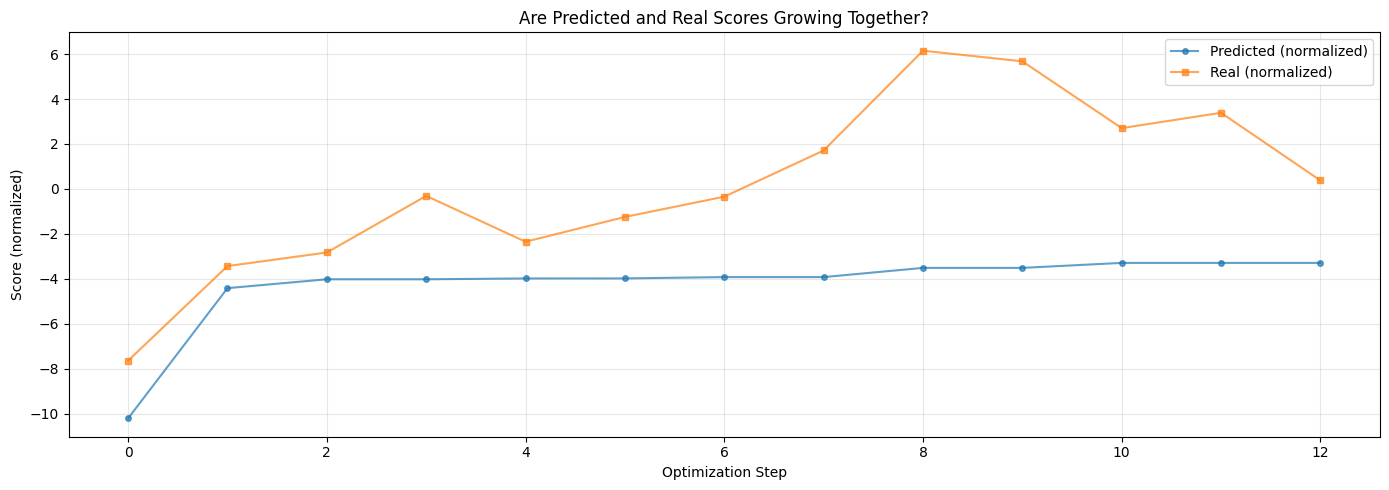

In [8]:
# Lookup real values for mutated sequences by oracle
values_df = pd.DataFrame(values)
values_df['real_score'] = values_df['mutation'].apply(lambda seq: oracle.inference(torch.tensor(seq, dtype=torch.float32)).item())
values_df['error'] = np.abs(values_df['real_score'] - values_df['predicted_score'])
plot_results(values_df)

/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


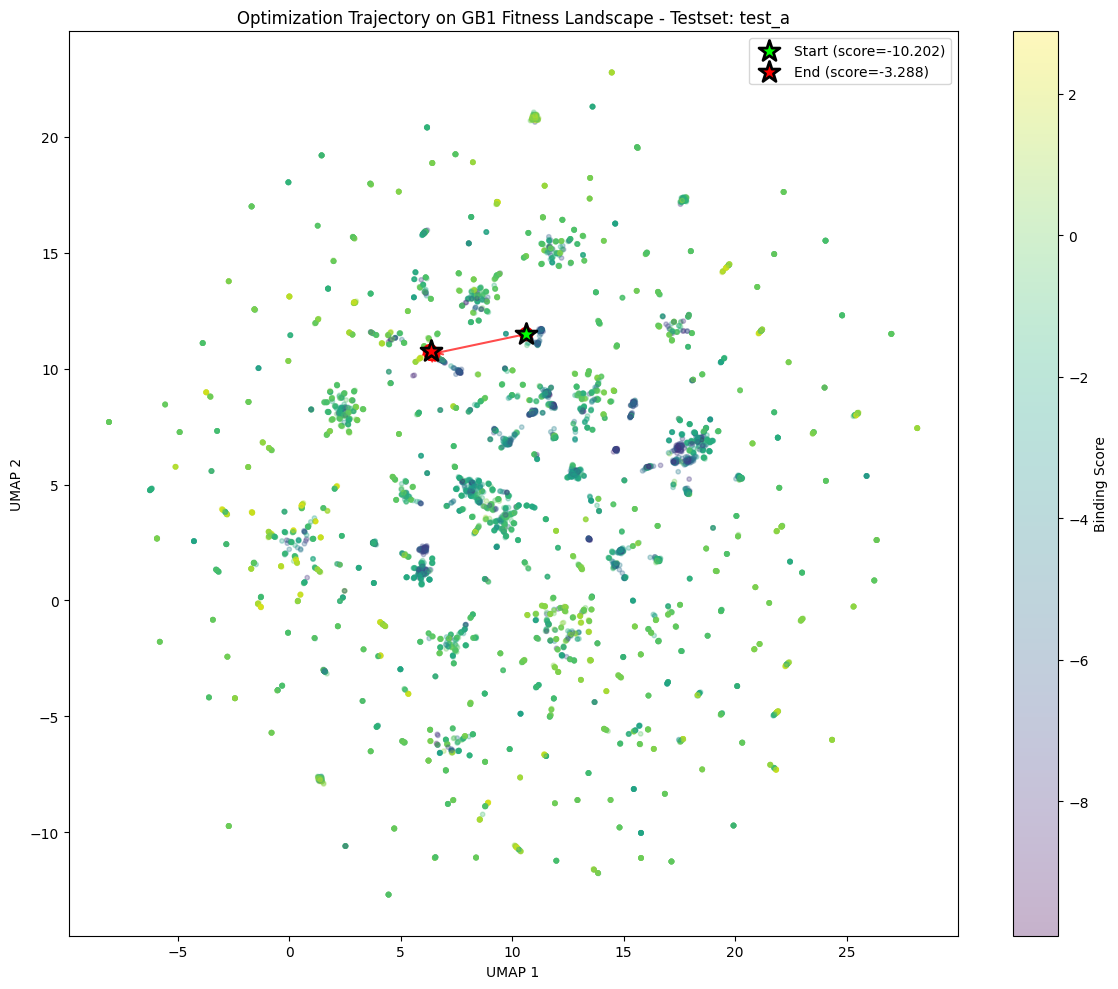

In [9]:
plot_umap_embedding(df, 'test_a', values_df)

2026-02-24 14:20:32.004651: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 410643200 exceeds 10% of free system memory.
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


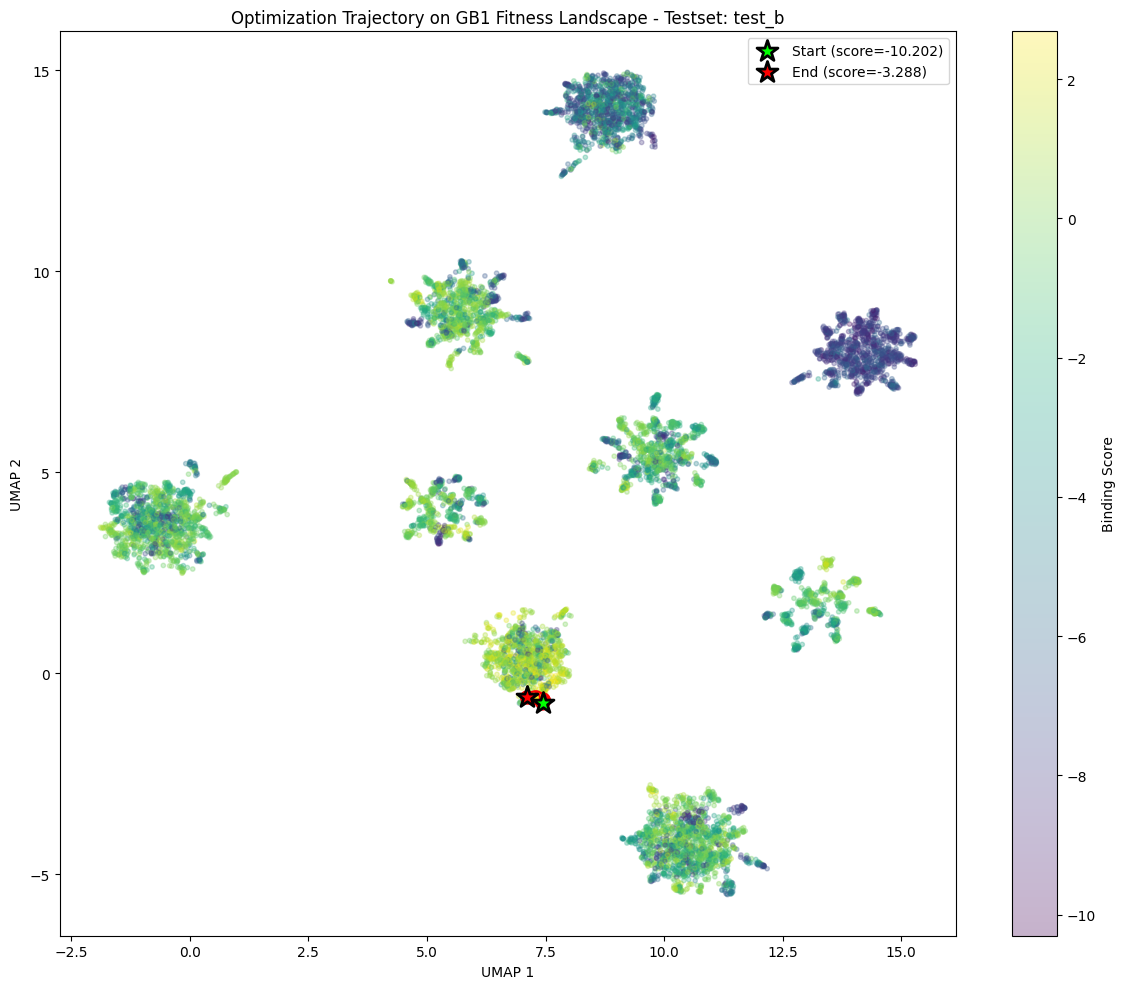

In [10]:
plot_umap_embedding(df, 'test_b', values_df)

2026-02-24 14:20:43.769930: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1757610800 exceeds 10% of free system memory.
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


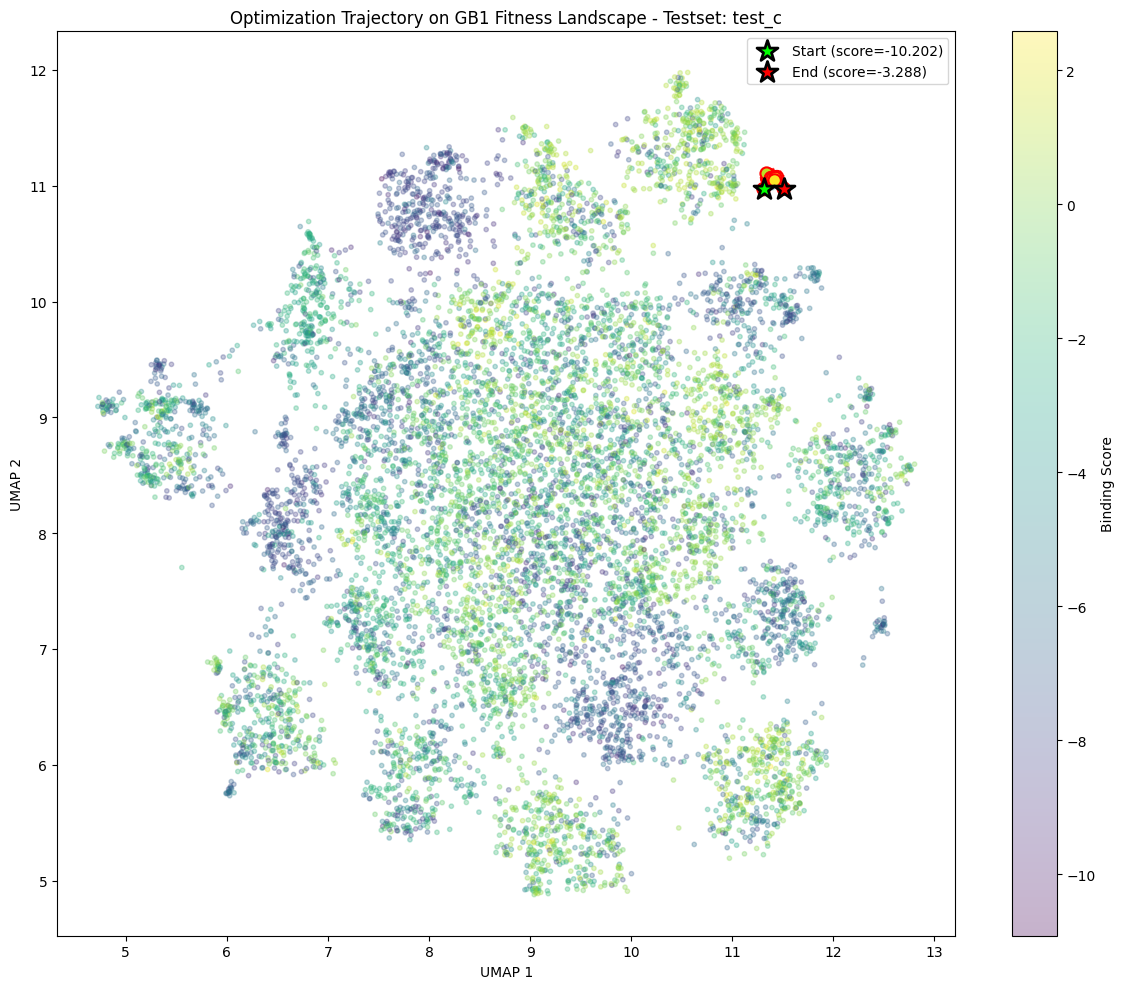

In [11]:
plot_umap_embedding(df, 'test_c', values_df)

### Mutate with SMW - Score with LSTM

In [12]:
from models.lstm import LSTMSequencePredictor, train, train_with_ranking, save_model, load_model

In [7]:
# Train LSTM Model with ranking-aware loss
# This ensures the model learns to RANK sequences correctly, not just predict absolute scores

lstm_model = LSTMSequencePredictor(input_size=20, lstm_units=128, dense_units=32)

# Use ranking-aware training: ranking_weight=0.5 means 50% ranking loss, 50% MSE
history = train_with_ranking(
    lstm_model, X_train_onehot, y_train, X_val_onehot, y_val,
    epochs=100,
    batch_size=64,
    lr=0.001,
    ranking_weight=0.5,  # Balance between MSE and ranking
    margin=0.1           # Minimum score difference to consider
)

save_model(lstm_model, 'lstm_scorer_GB1.pt')

# Quick sanity check: does model predict different scores for different sequences?
print("\n--- Sanity Check: Score Variance ---")
test_preds = [lstm_model.predict(X_val_onehot[i]) for i in range(min(20, len(X_val_onehot)))]
print(f"Predictions range: [{min(test_preds):.3f}, {max(test_preds):.3f}]")
print(f"Predictions std: {np.std(test_preds):.4f}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.14 GiB. GPU 0 has a total capacity of 3.63 GiB of which 844.25 MiB is free. Including non-PyTorch memory, this process has 2.80 GiB memory in use. Of the allocated memory 160.64 MiB is allocated by PyTorch, and 13.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Low fitness candidates:
                                                 sequence  binding_scores
405281  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYALDNGVDHEWTYDD...      -10.896890
374337  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYALDNEVDGEWTYDD...      -10.611447
306750  QYKLILNGKTLKGETTTEAVDAATAEKVFRQYANDNGVDGEQTYDD...      -10.424484
379108  QPKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGKDGEWTYDD...      -10.389586
14526   QYPLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEQTYDD...      -10.376513
306434  QYKLILNGKTLKGETTTEAVDAATAEKVFVQYANDNGADGEWTYDD...      -10.332705
513299  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEQTYDD...      -10.307343
441461  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEQTYWD...      -10.251153
474214  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEQTYDD...      -10.224302
287457  QYKLPLNGKTLKGETTTEAVDAATAEKVMKQYANDNGVDGEWTYDD...      -10.203301

Seed sequence: QYKLILNGKTLKGETTTEAVDAATAEKVFKQYALDNEVDGEWTYDDATKTFTVTE
Computed seed score: -8.1242
Step 1: Score -4.2244 (improved from -8.1242)
Step 2: Score -

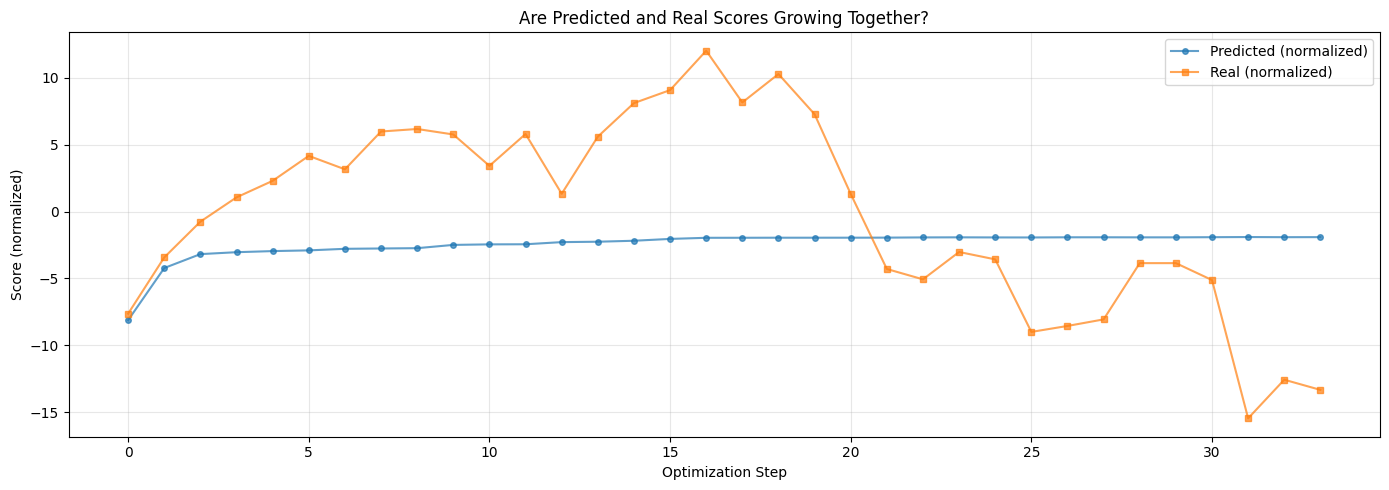

In [13]:
lstm_model = load_model('lstm_scorer_GB1(1).pt', input_size=20)

# Use indices (0-19) for amino acids
AA_Indices = list(range(20))
smw = SMW(AA_Indices)

# Pick a LOW fitness seed (more room to improve!)
train_df = df[df['split'] == 'train']
low_fitness_seeds = train_df.nsmallest(20, 'binding_scores')
print("Low fitness candidates:")
print(low_fitness_seeds[['sequence', 'binding_scores']].head(10))

# Select one of the lowest fitness sequences
seed_idx = 1  # Change this to try different starting points
seed_sequence = low_fitness_seeds['encoded_sequence'].iloc[seed_idx]
print(f"\nSeed sequence: {low_fitness_seeds['sequence'].iloc[seed_idx]}")

# Run optimization - score_seed=None will auto-compute, use_exhaustive=True searches ALL single mutations
values = mutate_score_sequence_GB1(
    smw, lstm_model, seed_sequence, 
    score_seed=None,           # Auto-compute from LSTM
    steps=50,                  # Number of greedy steps
    use_exhaustive=False,       # Search ALL single-point mutations
    top_k=5,                   
    acceptance_threshold=0.5,  # Only accept improvements
    patience=5                 # Restart after 5 steps without improvement
)

values = pd.DataFrame(values)
if len(values) > 0:
    values['real_score'] = values['mutation'].apply(lambda seq: oracle.inference(torch.tensor(seq, dtype=torch.float32)).item())
    values['error'] = np.abs(values['real_score'] - values['predicted_score'])
    plot_results(values)
else:
    print("No improvements found - try a different seed or check scorer predictions")

### Plot Optimization Trajectory on Fitness Landscape

/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


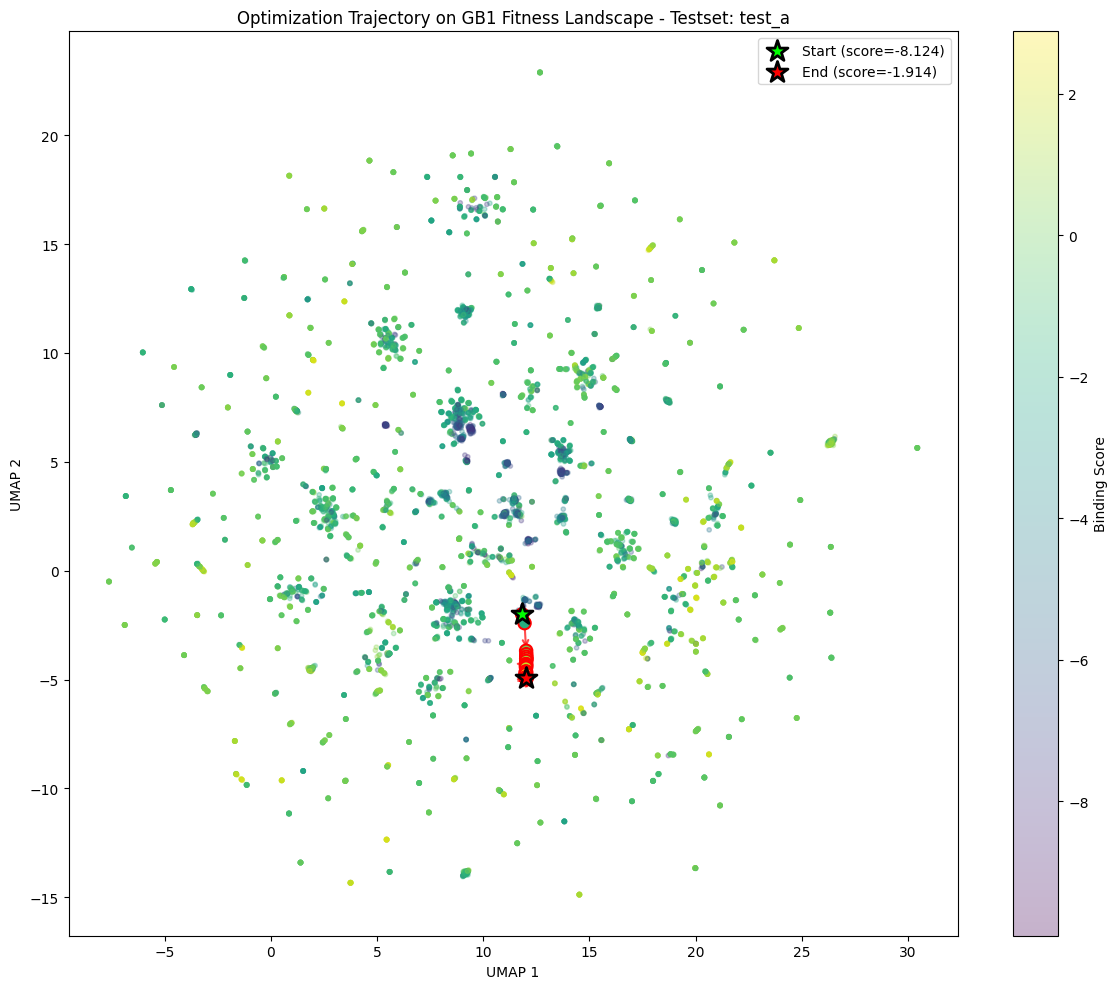

In [15]:
plot_umap_embedding(df, 'test_a', values)

2026-02-24 14:22:37.197424: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 410643200 exceeds 10% of free system memory.
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


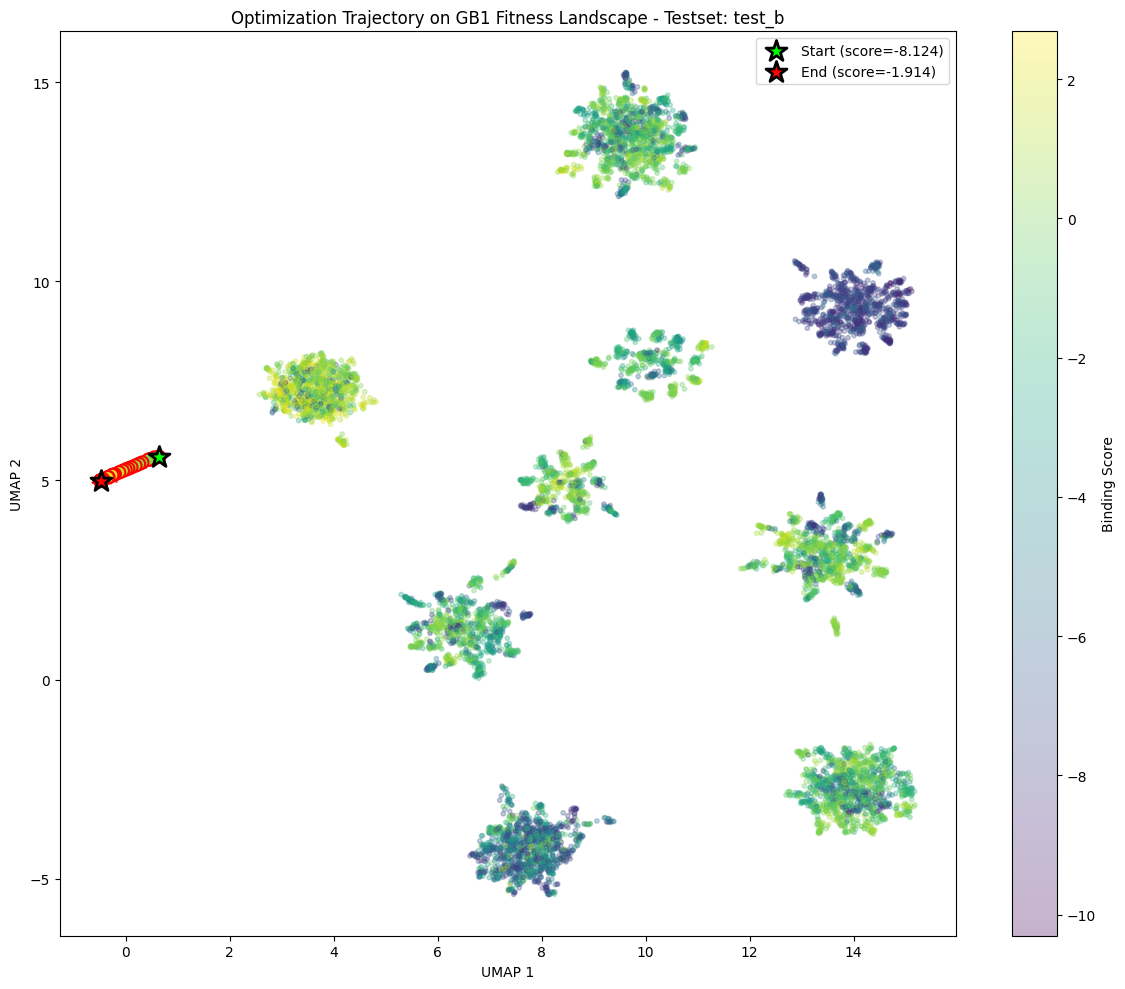

In [16]:
plot_umap_embedding(df, 'test_b', values)

2026-02-24 14:22:50.539024: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1757610800 exceeds 10% of free system memory.
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


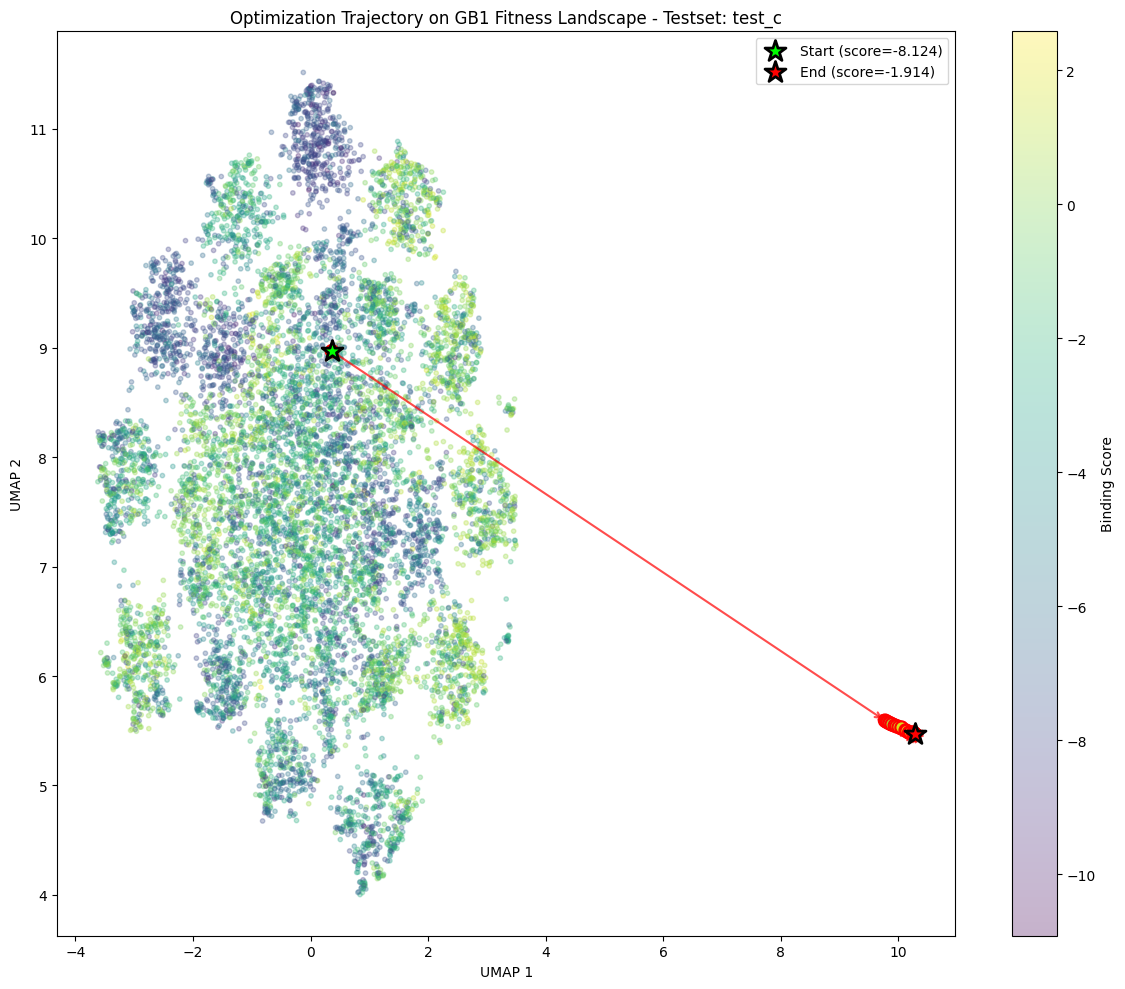

In [17]:
plot_umap_embedding(df, 'test_c', values)